<a href="https://colab.research.google.com/github/LucasPuertas95/Aprendizaje-Automatico-1/blob/main/Escalamiento%20de%20Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practica de Escalamiento de Datos
***TRABAJANDO CON EL EJERCIO DE LA PAGINA DE ScikitLEARN***

**LUCAS PUERTAS**

Codigo desde la pagina de Scikit Learn

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

feature_mapping = {
    "MedInc": "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupancy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

# Take only 2 features to make visualization easier
# Feature MedInc has a long tail distribution.
# Feature AveOccup has a few but very large outliers.
features = ["MedInc", "AveOccup"]
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]
distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    ("Data after robust scaling", RobustScaler(quantile_range=(25, 75)).fit_transform(X),),
    ("Data after power transformation (Yeo-Johnson)", PowerTransformer(method="yeo-johnson").fit_transform(X),),
    ("Data after power transformation (Box-Cox)",PowerTransformer(method="box-cox").fit_transform(X),),
    ("Data after quantile transformation (uniform pdf)",QuantileTransformer(output_distribution="uniform", random_state=42).fit_transform(X),
    ),
    ("Data after quantile transformation (gaussian pdf)",QuantileTransformer(output_distribution="normal", random_state=42).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]

# scale the output between 0 and 1 for the colorbar
y = minmax_scale(y_full)

# plasma does not exist in matplotlib < 1.5
cmap = getattr(cm, "plasma_r", cm.hot_r)


def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # define the axis for the first plot
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # define the axis for the zoomed-in plot
    left = width + left + 0.2
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # define the axis for the colorbar
    left, width = width + left + 0.13, 0.01

    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )


def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # The scatter plot
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=1.0, marker="o", s=10, lw=0.3, edgecolor="black", c=colors)

    # Removing the top and the right spine for aesthetics
    # make nice axis layout
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Histogram for axis X1 (feature 5)
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    hist_X1.axis("off")

    # Histogram for axis X0 (feature 0)
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    hist_X0.axis("off")


In [ ]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

# StandarScaler
**¿Qué hace matemáticamente?**: Transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Es como mover el centro de tu "nube" de puntos al origen (0,0) y estirarla o encogerla para que la mayoría de los datos estén entre -1 y 1.

**Tratamiento de outliers:** Es muy sensible. Como usa la media para calcular el centro, un solo valor extremadamente alto "tira" de la media hacia él, haciendo que el resto de los puntos normales se vean muy apretados en el gráfico.

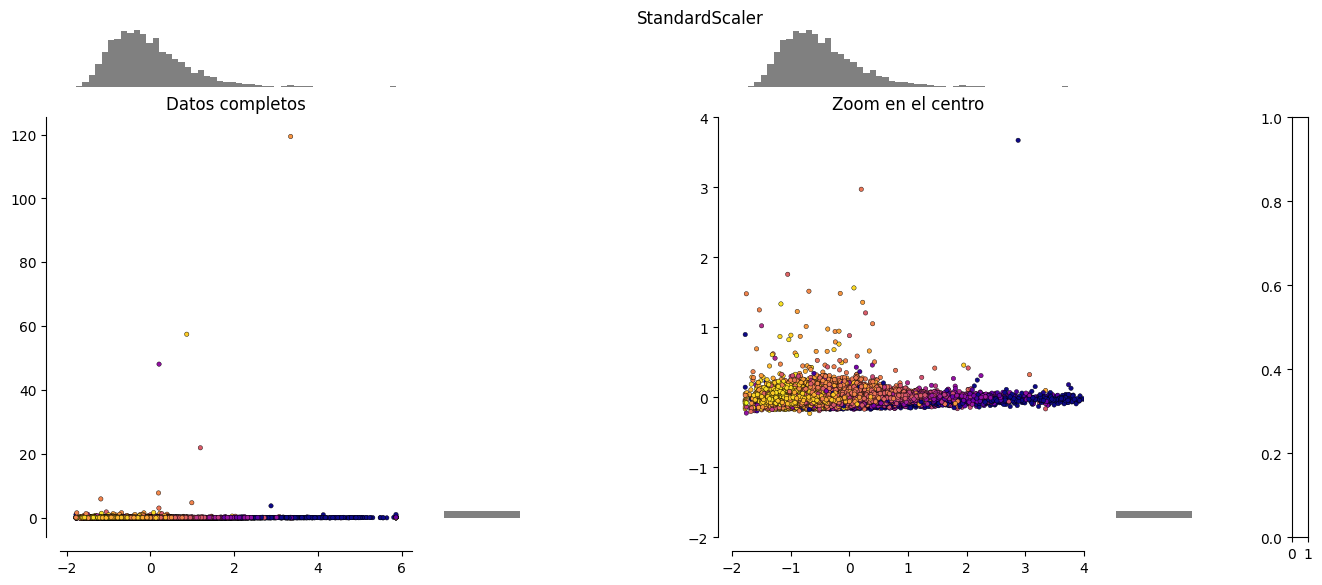

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes("StandardScaler")
plot_distribution(ax_zoom_out, X_scaled, y, title="Datos completos")
plot_distribution(ax_zoom_in, X_scaled, y, title="Zoom en el centro")
ax_zoom_in[0].set_xlim(-2, 4)
ax_zoom_in[0].set_ylim(-2, 4)
plt.show()

# MinMaxScaler
**¿Qué hace matemáticamente?:** Escala los datos a un rango fijo, generalmente entre 0 y 1. Toma el valor más pequeño y lo hace 0, y el más grande y lo hace 1.

**Tratamiento de outliers:** Es el que peor los maneja. Si tienes un outlier gigante, ese será el "1", y todos tus otros datos (que quizás están mucho más abajo) se verán como una mancha minúscula pegada al "0" porque el scaler tiene que dejar espacio para llegar hasta el valor atípico.

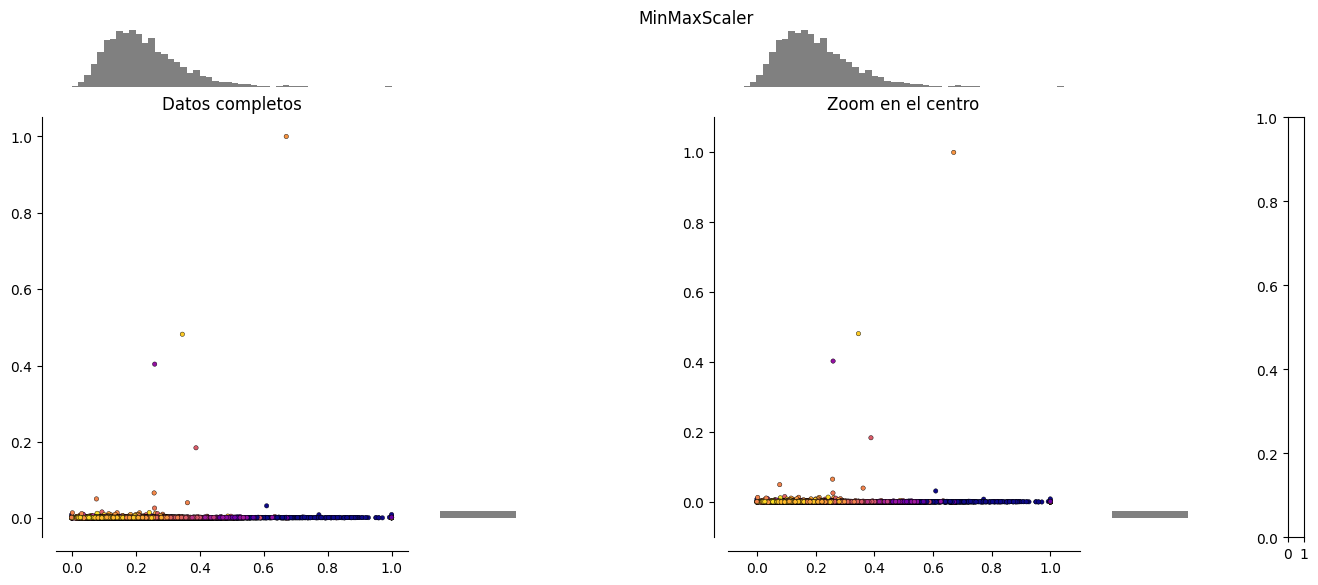

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes("MinMaxScaler")
plot_distribution(ax_zoom_out, X_scaled, y, title="Datos completos")
plot_distribution(ax_zoom_in, X_scaled, y, title="Zoom en el centro")
ax_zoom_in[0].set_xlim(-0.1, 1.1)
ax_zoom_in[0].set_ylim(-0.1, 1.1)
plt.show()

# RobustScaler
**¿Qué hace matemáticamente?:** En lugar de usar la media, usa la mediana (el valor central real) y el rango intercuartílico (la distancia entre el 25% y el 75% de los datos).

**Tratamiento de outliers:** Es el mejor para este caso. Al ignorar los valores extremos para calcular la escala, logra que el grueso de los datos se vea bien distribuido, dejando que los outliers queden "lejos" pero sin arruinar la visualización de los puntos importantes.

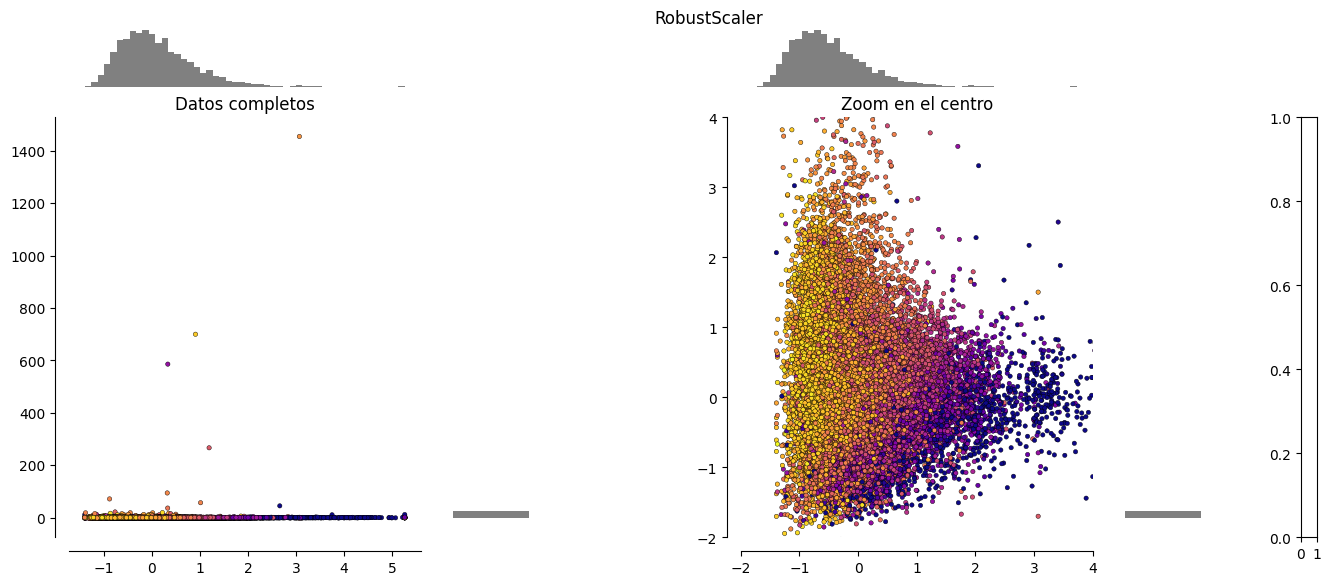

In [ ]:
scaler = RobustScaler(quantile_range=(25, 75))
X_scaled = scaler.fit_transform(X)

ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes("RobustScaler")
plot_distribution(ax_zoom_out, X_scaled, y, title="Datos completos")
plot_distribution(ax_zoom_in, X_scaled, y, title="Zoom en el centro")
ax_zoom_in[0].set_xlim(-2, 4)
ax_zoom_in[0].set_ylim(-2, 4)
plt.show()

# PowerTransformer (Yeo-Johnson)

**¿Qué hace matemáticamente?:** Aplica una transformación de potencia paramétrica para que los datos se aproximen lo más posible a una distribución Gaussiana (Normal). Se usa principalmente para estabilizar la varianza y eliminar la asimetría.

**Tratamiento de outliers:** Es muy efectivo. Al intentar "normalizar" la campana, comprime las colas largas. Los valores que estaban extremadamente lejos son empujados hacia el centro de la distribución para que el conjunto parezca una "bola" más simétrica.

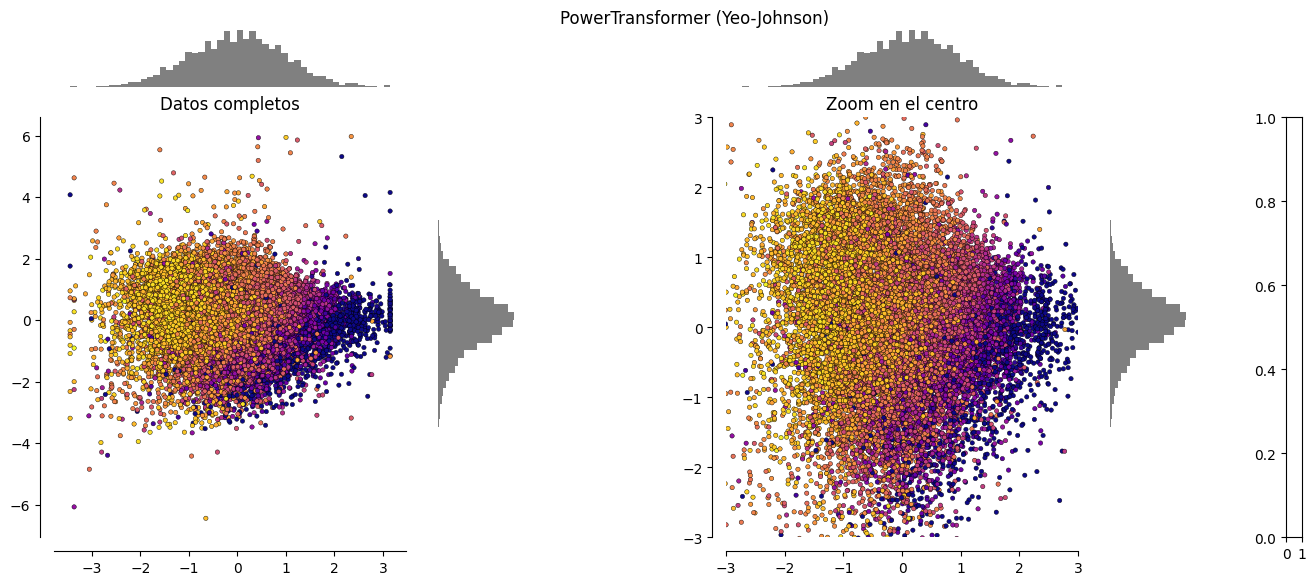

In [ ]:
scaler = PowerTransformer(method="yeo-johnson")
X_scaled = scaler.fit_transform(X)

ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes("PowerTransformer (Yeo-Johnson)")
plot_distribution(ax_zoom_out, X_scaled, y, title="Datos completos")
plot_distribution(ax_zoom_in, X_scaled, y, title="Zoom en el centro")
ax_zoom_in[0].set_xlim(-3, 3)
ax_zoom_in[0].set_ylim(-3, 3)
plt.show()

# QuantileTransformer (Distribución Uniforme)

**¿Qué hace matemáticamente?:** Esta es una transformación no lineal. Mapea los datos a una distribución uniforme basándose en los cuantiles. En términos simples: "obliga" a que haya la misma cantidad de puntos en todas las áreas del gráfico, rompiendo la estructura original.

**Tratamiento de outliers:** Los elimina por completo en términos de impacto visual. Como se basa en el orden de los datos y no en su valor real, un outlier gigante simplemente se convierte en el "punto más alto", pero queda pegado al resto de los puntos. En la gráfica verás que el zoom y el dato completo se ven casi iguales: un cuadrado perfecto de puntos.

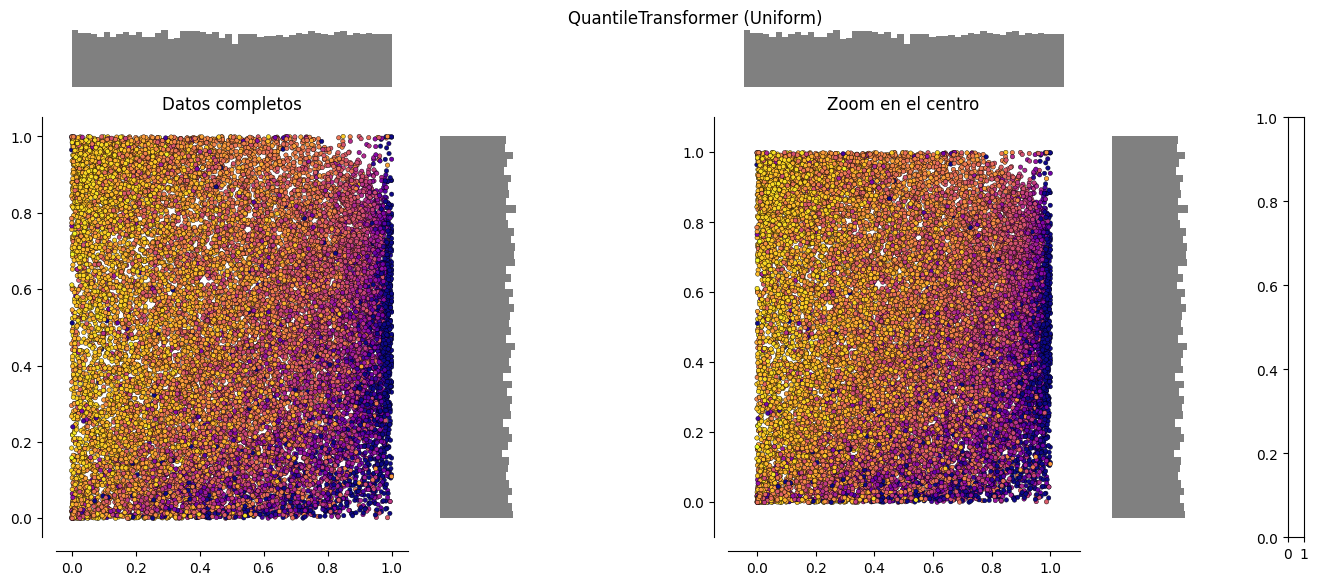

In [ ]:
scaler = QuantileTransformer(output_distribution="uniform", random_state=42)
X_scaled = scaler.fit_transform(X)

ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes("QuantileTransformer (Uniform)")
plot_distribution(ax_zoom_out, X_scaled, y, title="Datos completos")
plot_distribution(ax_zoom_in, X_scaled, y, title="Zoom en el centro")
ax_zoom_in[0].set_xlim(-0.1, 1.1)
ax_zoom_in[0].set_ylim(-0.1, 1.1)
plt.show()

# Normalizer

**¿Qué hace matemáticamente?:** A diferencia de todos los anteriores, el Normalizer trabaja por fila (por muestra) y no por columna. Escala cada punto para que su vector tenga una "norma" (longitud) igual a 1. Matemáticamente, proyecta cada punto sobre un círculo unitario.

**Tratamiento de outliers:** No los elimina, sino que los "doma" proyectándolos. Si un punto tenía una ocupación de 1500, el Normalizer lo mueve sobre el borde de un círculo. Lo interesante aquí es que la estructura de "nube" desaparece y los puntos empiezan a dibujar formas curvas o circulares.

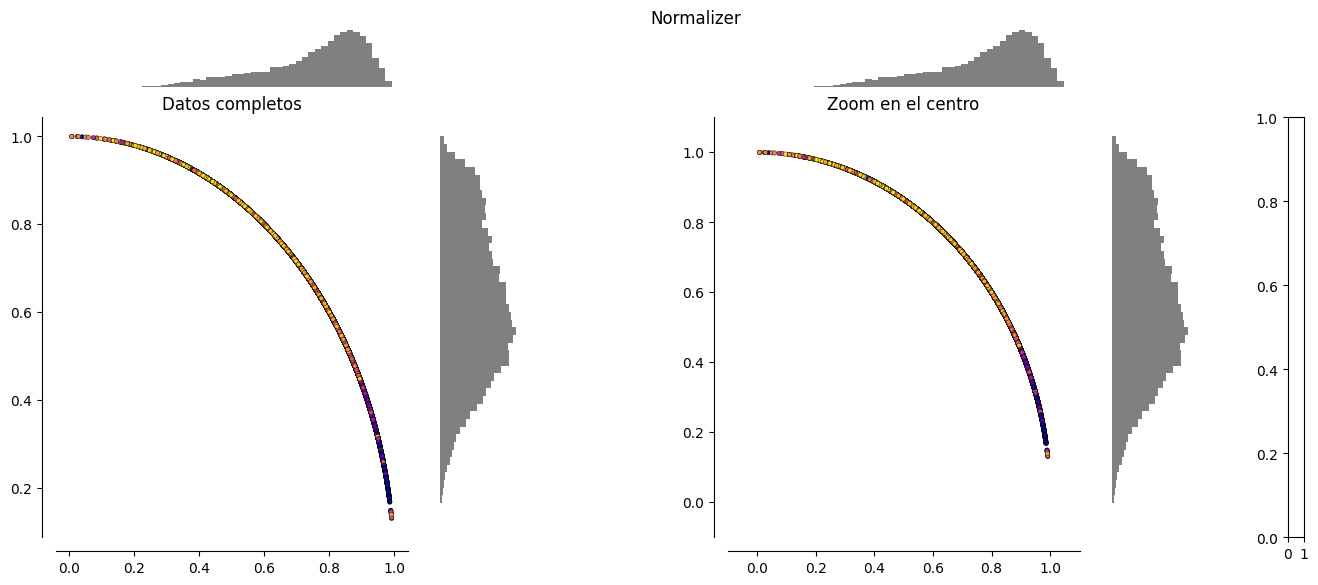

In [ ]:
scaler = Normalizer()
X_scaled = scaler.fit_transform(X)

ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes("Normalizer")
plot_distribution(ax_zoom_out, X_scaled, y, title="Datos completos")
plot_distribution(ax_zoom_in, X_scaled, y, title="Zoom en el centro")
# Como proyecta en un círculo de radio 1, ajustamos el zoom a ese rango
ax_zoom_in[0].set_xlim(-0.1, 1.1)
ax_zoom_in[0].set_ylim(-0.1, 1.1)
plt.show()

# Cuestionario:
 ***1 Sensibilidad a los valores atípicos***

¿Qué sucede con la masa principal de los datos (el "cuadrado" denso) cuando hay valores atípicos muy alejados? ¿Por qué estos escaladores podrían ser problemáticos en este escenario?

***2 Robustez***

Por qué el RobustScaler logra mantener el "zoom" en la mayoría de los datos a pesar de que los ejes sigan mostrando los valores extremos. ¿Qué estadísticos utiliza para lograr esto?

***3 Normalización de la distribución***

El PowerTransformer (método Yeo-Johnson) y el QuantileTransformer (salida Gaussiana) intentan forzar los datos hacia una distribución normal.
¿Qué diferencias visuales notas entre ellos?
¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?

***4 El caso del Normalizer***

El Normalizer muestra un gráfico muy distinto a todos los demás (con una forma circular o arqueada).
¿Por qué este escalador actúa sobre las filas (muestras) en lugar de las columnas (características)?
Investiga un caso de uso (como procesamiento de texto o química) donde este comportamiento sea deseable.

***5 Conclusión técnica***

Si estuvieras entrenando un modelo de regresión lineal para predecir el precio de las casas y notas que la variable "ingreso medio" tiene muchos valores atípicos, ¿cuál de todos los métodos probados elegirías y por qué?

# Respuestas

**1. Sensibilidad a los valores atípicos**

En ambos casos, la masa principal de los datos se ve comprimida o "aplastada" en un rincón del gráfico. Al observar tanto la vista completa como el zoom, descubrimos que el escalador aplica la transformación a todo el conjunto al mismo tiempo; por lo tanto, para poder incluir al outlier en el nuevo rango (0 a 1 en MinMax), el escalador estira tanto la escala que los datos normales quedan reducidos a una mancha minúscula.
Por qué es problemático: Estos escaladores "se dejan mandar" por el outlier. Al cambiar las etiquetas de valor basándose en los extremos, la mayoría de los datos pierden resolución numérica, lo que hace que el modelo de Machine Learning tenga dificultades para distinguir diferencias entre los datos normales.

**2. Robustez**

El RobustScaler logra mantener un zoom útil porque su "magia" consiste en ignorar a los valores extremos para decidir dónde poner el marco del cuadro. A diferencia de los anteriores, no permite que las etiquetas de los outliers dicten el tamaño de la escala para los demás.
Estadísticos utilizados: Utiliza la Mediana (en lugar de la media) y el Rango Intercuartílico (IQR) (la distancia entre el percentil 25 y 75). Al centrarse en donde está "lo normal", el 50% central de los datos siempre ocupa un lugar protagonista en el zoom, sin importar qué tan lejos estén los atípicos en los ejes.

**3. Normalización de la distribución**

Diferencias visuales: El PowerTransformer intenta "redondear" la nube de puntos hacia una forma de campana, pero mantiene cierta estructura de la densidad original.

El QuantileTransformer es mucho más agresivo: "rompe" la forma original y la fuerza a ser un cuadrado perfecto (uniforme) o una bola perfecta (Gaussiana). En la lupa, verás que los datos están repartidos de forma mucho más homogénea.
Beneficio en modelos: Sería más beneficioso en modelos que asumen que los datos siguen una distribución normal, como la Regresión Lineal, Análisis Discriminante Lineal (LDA) o modelos basados en distancias como KNN. Estos modelos funcionan mucho más rápido y con menos errores cuando los datos tienen una forma "limpia" y simétrica.

**4. El caso del Normalizer**
Comportamiento por filas: El Normalizer no escala "columnas" (variables), sino que escala cada "fila" (un registro individual) para que su magnitud total sea 1. Esto proyecta los datos sobre un círculo o arco porque lo que importa no es "cuánto" vale cada variable, sino la proporción entre ellas.
Caso de uso: Es fundamental en el Procesamiento de Lenguaje Natural (NLP). Cuando comparamos dos documentos, no importa si uno tiene 100 palabras y el otro 1000; lo que importa es la frecuencia relativa de las palabras. Al normalizar, el modelo puede comparar "temas" sin distraerse por el largo del texto.

**5. Conclusión técnica**

Elegiría el RobustScaler.

En base a lo descubierto, este método es el que mejor "optimiza el encuadre" para el modelo. Como las variables tienen muchos outliers, el RobustScaler permitirá que el modelo de regresión "vea" con claridad las diferencias en los ingresos de la mayoría de la población (el zoom detallado), sin que las mansiones de lujo (outliers) encandilen al algoritmo o aplasten la escala. Al mantener las etiquetas de los outliers en valores distantes pero no destructivos, conservamos la información sin perder la resolución de la masa principal de datos.